In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

#databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

from matplotlib.ticker import FuncFormatter

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


In [2]:
# --- First pass: organize systems into a structure {replica: {forcefield: system}} ---
grid = {}

#protein_system = 'KRS1-72_salt'
protein_system = 'ChiZ_salt'
#protein_system = 'asyn_salt'
#protein_system = 'icl2'

for system in systems:
    if protein_system not in system['SYSTEM']:
        continue

    trj = system['TRJ'][0][0]

    # Example: KRS1-72_replica_05_AMBER03WS_2000ns.xtc
    match = re.search(r"replica_(\d+)_([A-Za-z0-9\-]+)_", trj)
    #match = re.search(r"replica_(\d+)_([A-Za-z0-9]+)_", trj)
    if not match:
        print("Could not parse:", trj)
        continue

    replica = match.group(1)
    forcefield = match.group(2)

    if replica not in grid:
        grid[replica] = {}
    grid[replica][forcefield] = system


# --- Determine sorted order of replicas and forcefields ---
replicas = sorted(grid.keys(), key=lambda x: int(x))

desired_order = [
    "AMBER03WS",
    "AMBER99SB-DISP",
    "AMBER99SBWS",
    "DESAMBER",
    "CHARMM36M",
]

forcefields = sorted(
    {ff for rep in grid.values() for ff in rep.keys()},
    key=lambda ff: desired_order.index(ff)
)
print(forcefields)

#forcefields = sorted(
#    {ff for rep in grid.values() for ff in rep.keys()}
#)
#print(forcefields)

n_rows = len(replicas)
n_cols = len(forcefields)# * 2   # because each system has 2 images (chem + relax)

#fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))


['AMBER03WS', 'AMBER99SB-DISP', 'AMBER99SBWS', 'DESAMBER', 'CHARMM36M']


In [20]:
def plot_quality_heatmap(data_dict, ax, vmax=None,
                         show_residue_labels=True, show_nucleus_labels=True):
    """
    Plot a heatmap onto a provided axis `ax`.
    No colorbar is created here; caller handles shared colorbar.
    """

    # --- Prepare data ---
    df = pd.DataFrame(data_dict).T

    # Extract "Averages" and sort
    if "Averages" in df.index:
        averages = df.loc["Averages"]
        df = df.drop("Averages")
    else:
        averages = None

    # Sort residues numerically
    def residue_sort_key(name):
        m = re.match(r"(\d+)", str(name))
        return int(m.group(1)) if m else float("inf")

    df = df.loc[sorted(df.index, key=residue_sort_key)]

    # Add Averages row back at bottom
    if averages is not None:
        df.loc["Averages"] = averages

    # Transpose for plotting
    df_t = df.T

    # --- Plot heatmap (NO colorbar!) ---
    sns.heatmap(
        df_t,
        cmap="RdYlGn_r",
        vmax=vmax,
        linewidths=0.5,
        cbar=False,
        ax=ax
    )

    # --- Axis labels ---
    if show_residue_labels:
        #ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=13)

        max_res = int(ax.get_xlim()[1])
        ticks = np.arange(10, max_res + 1, 10)

        ax.set_xticks(ticks)
        ax.set_xticklabels(ticks, rotation=90, fontsize=28)
        ax.set_xlabel("Residue", fontsize=35)
        
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")

    if show_nucleus_labels:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=28)
        for label in ax.get_yticklabels():
            label.set_fontsize(28)
        if label.get_text() == "hetNOE":
            label.set_rotation(90)
        else:
            label.set_rotation(0)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.set_title("")


In [27]:
import matplotlib.gridspec as gridspec

def plot_heatmap_grid(type_name, yaml_filename, vmax=None,
                      colorbar_width=0.05, colorbar_pad=0.02,
                      figsize_per_cell=(4, 4)):
    """
    Build a grid of heatmaps from per-system YAMLs (one YAML per simulation folder).
    Places a shared, non-overlapping colorbar in a dedicated GridSpec column.
    - yaml_filename: name of YAML file inside each system folder (e.g. "spin_relaxation_quality.yaml")
    - vmax: color scale upper limit (passed to plot_quality_heatmap)
    - colorbar_width: fraction of figure width allocated to colorbar column
    - colorbar_pad: gap between heatmaps and colorbar (as fraction of figure width)
    - figsize_per_cell: (width,height) of each heatmap cell in inches
    """

    # Number of rows/cols come from your grid (replicas, forcefields)
    n_rows = len(replicas)
    n_cols = len(forcefields)

    # Build figure width/height
    fig_w = figsize_per_cell[0] * n_cols + figsize_per_cell[0] * colorbar_width *  (1/figsize_per_cell[0])
    fig_h = figsize_per_cell[1] * n_rows
    # A simpler, reliable figsize:
    fig = plt.figure(figsize=(4 * n_cols + 1.0, 4 * n_rows))

    # GridSpec: data grid (n_rows x n_cols) + 1 column for colorbar
    gs = gridspec.GridSpec(
        n_rows,
        n_cols + 1,
        width_ratios=[1] * n_cols + [colorbar_width],
        wspace=0.05,
        hspace=0.05
    )

    # Create axes matrix for the heatmaps
    axes = [[fig.add_subplot(gs[r, c]) for c in range(n_cols)] for r in range(n_rows)]

    first_mappable = None  # will hold an artist for colorbar

    for r_idx, replica in enumerate(replicas):
        for c_idx, forcefield in enumerate(forcefields):
            ax = axes[r_idx][c_idx]

            # If no system for this cell, turn axis off
            if forcefield not in grid[replica]:
                ax.axis("off")
                continue

            system = grid[replica][forcefield]
            dataFolder = os.path.join('../../Data/Simulations', system['path'])
            yaml_path = os.path.join(dataFolder, yaml_filename)

            if not os.path.exists(yaml_path):
                ax.axis("off")
                continue

            # Load YAML dict
            with open(yaml_path, "r") as f:
                data_dict = yaml.safe_load(f)

            # Which outer labels to show
            show_x = (r_idx == n_rows - 1)   # residues only on bottom row
            show_y = (c_idx == 0)           # nucleus labels only on left column

            # Draw the heatmap onto the provided axis (plot_quality_heatmap should use cbar=False)
            plot_quality_heatmap(
                data_dict=data_dict,
                ax=ax,
                vmax=vmax,
                show_residue_labels=show_x,
                show_nucleus_labels=show_y
            )

            # seaborn heatmap creates QuadMesh in ax.collections (index 0)
            # Save first mappable for colorbar
            if first_mappable is None:
                # prefer QuadMesh (image) or collection
                if len(ax.collections) > 0:
                    first_mappable = ax.collections[0]
                else:
                    # fallback: try the last image
                    imgs = ax.get_images()
                    if len(imgs) > 0:
                        first_mappable = imgs[-1]

            # Column titles on first row
            if r_idx == 0:
                ax.set_title(forcefield, fontsize=30, fontweight="bold")

            # Row label on leftmost column
            if c_idx == 0:
                ax.set_ylabel(f"Replica {replica}", fontsize=35, fontweight="bold")

    # If we found no mappable (nothing plotted), just return the figure
    if first_mappable is None:
        fig.suptitle(type_name, fontsize=35, fontweight="bold")
        fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.05)
        plt.show()
        return fig

    # --------------------------
    # Add a dedicated colorbar axis (entire last column)
    # --------------------------
    cax = fig.add_subplot(gs[:, -1])  # span all rows in the last column
    # Draw the colorbar vertically in that axis
    cb = fig.colorbar(first_mappable, cax=cax, orientation="vertical")
    # Optionally tweak colorbar label size/ticks here:

    cb.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x + 1:g}")
    )
   
    cb.ax.tick_params(labelsize=30)

    # --------------------------
    # Final layout adjustments (do NOT use tight_layout)
    # --------------------------
    fig.suptitle(type_name, fontsize=35, fontweight="bold")

    # Manually adjust margins so the colorbar column won't be overlapped
    fig.subplots_adjust(
        left=0.03,    # space left edge
        right=0.97,   # right edge (colorbar fits in gs last column)
        top=0.92,
        bottom=0.05
    )

    plt.show()
    return fig


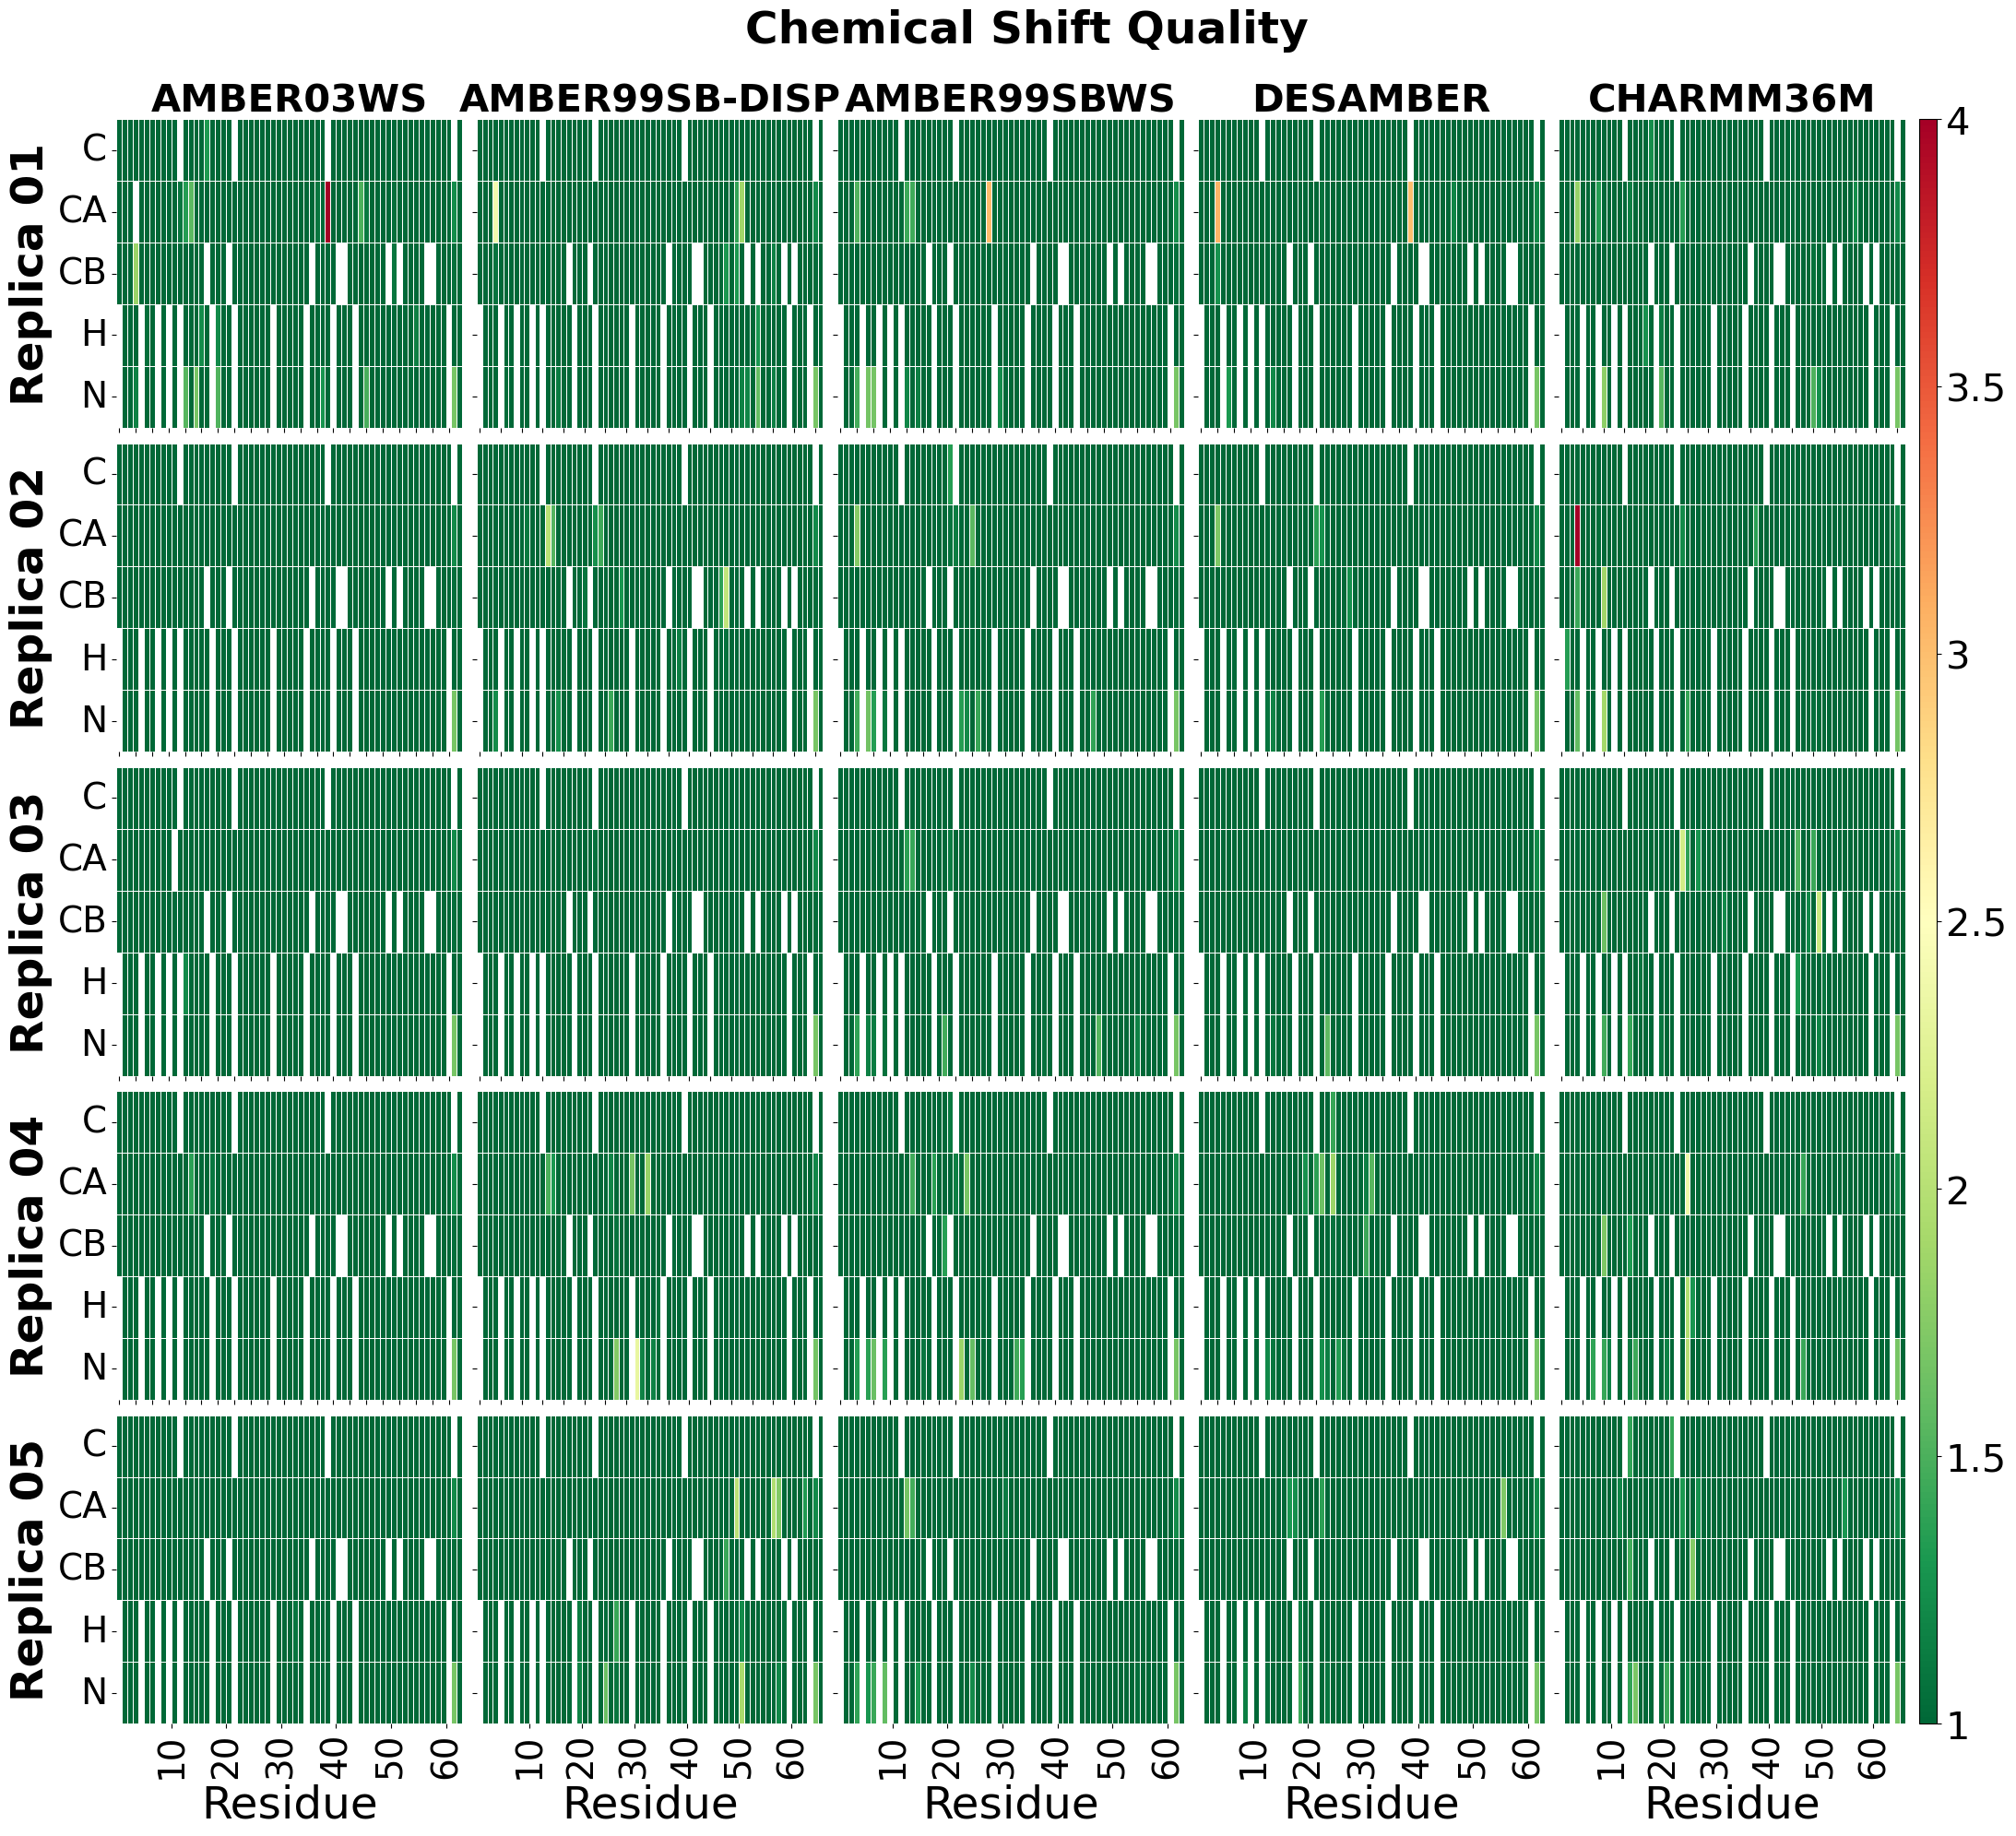

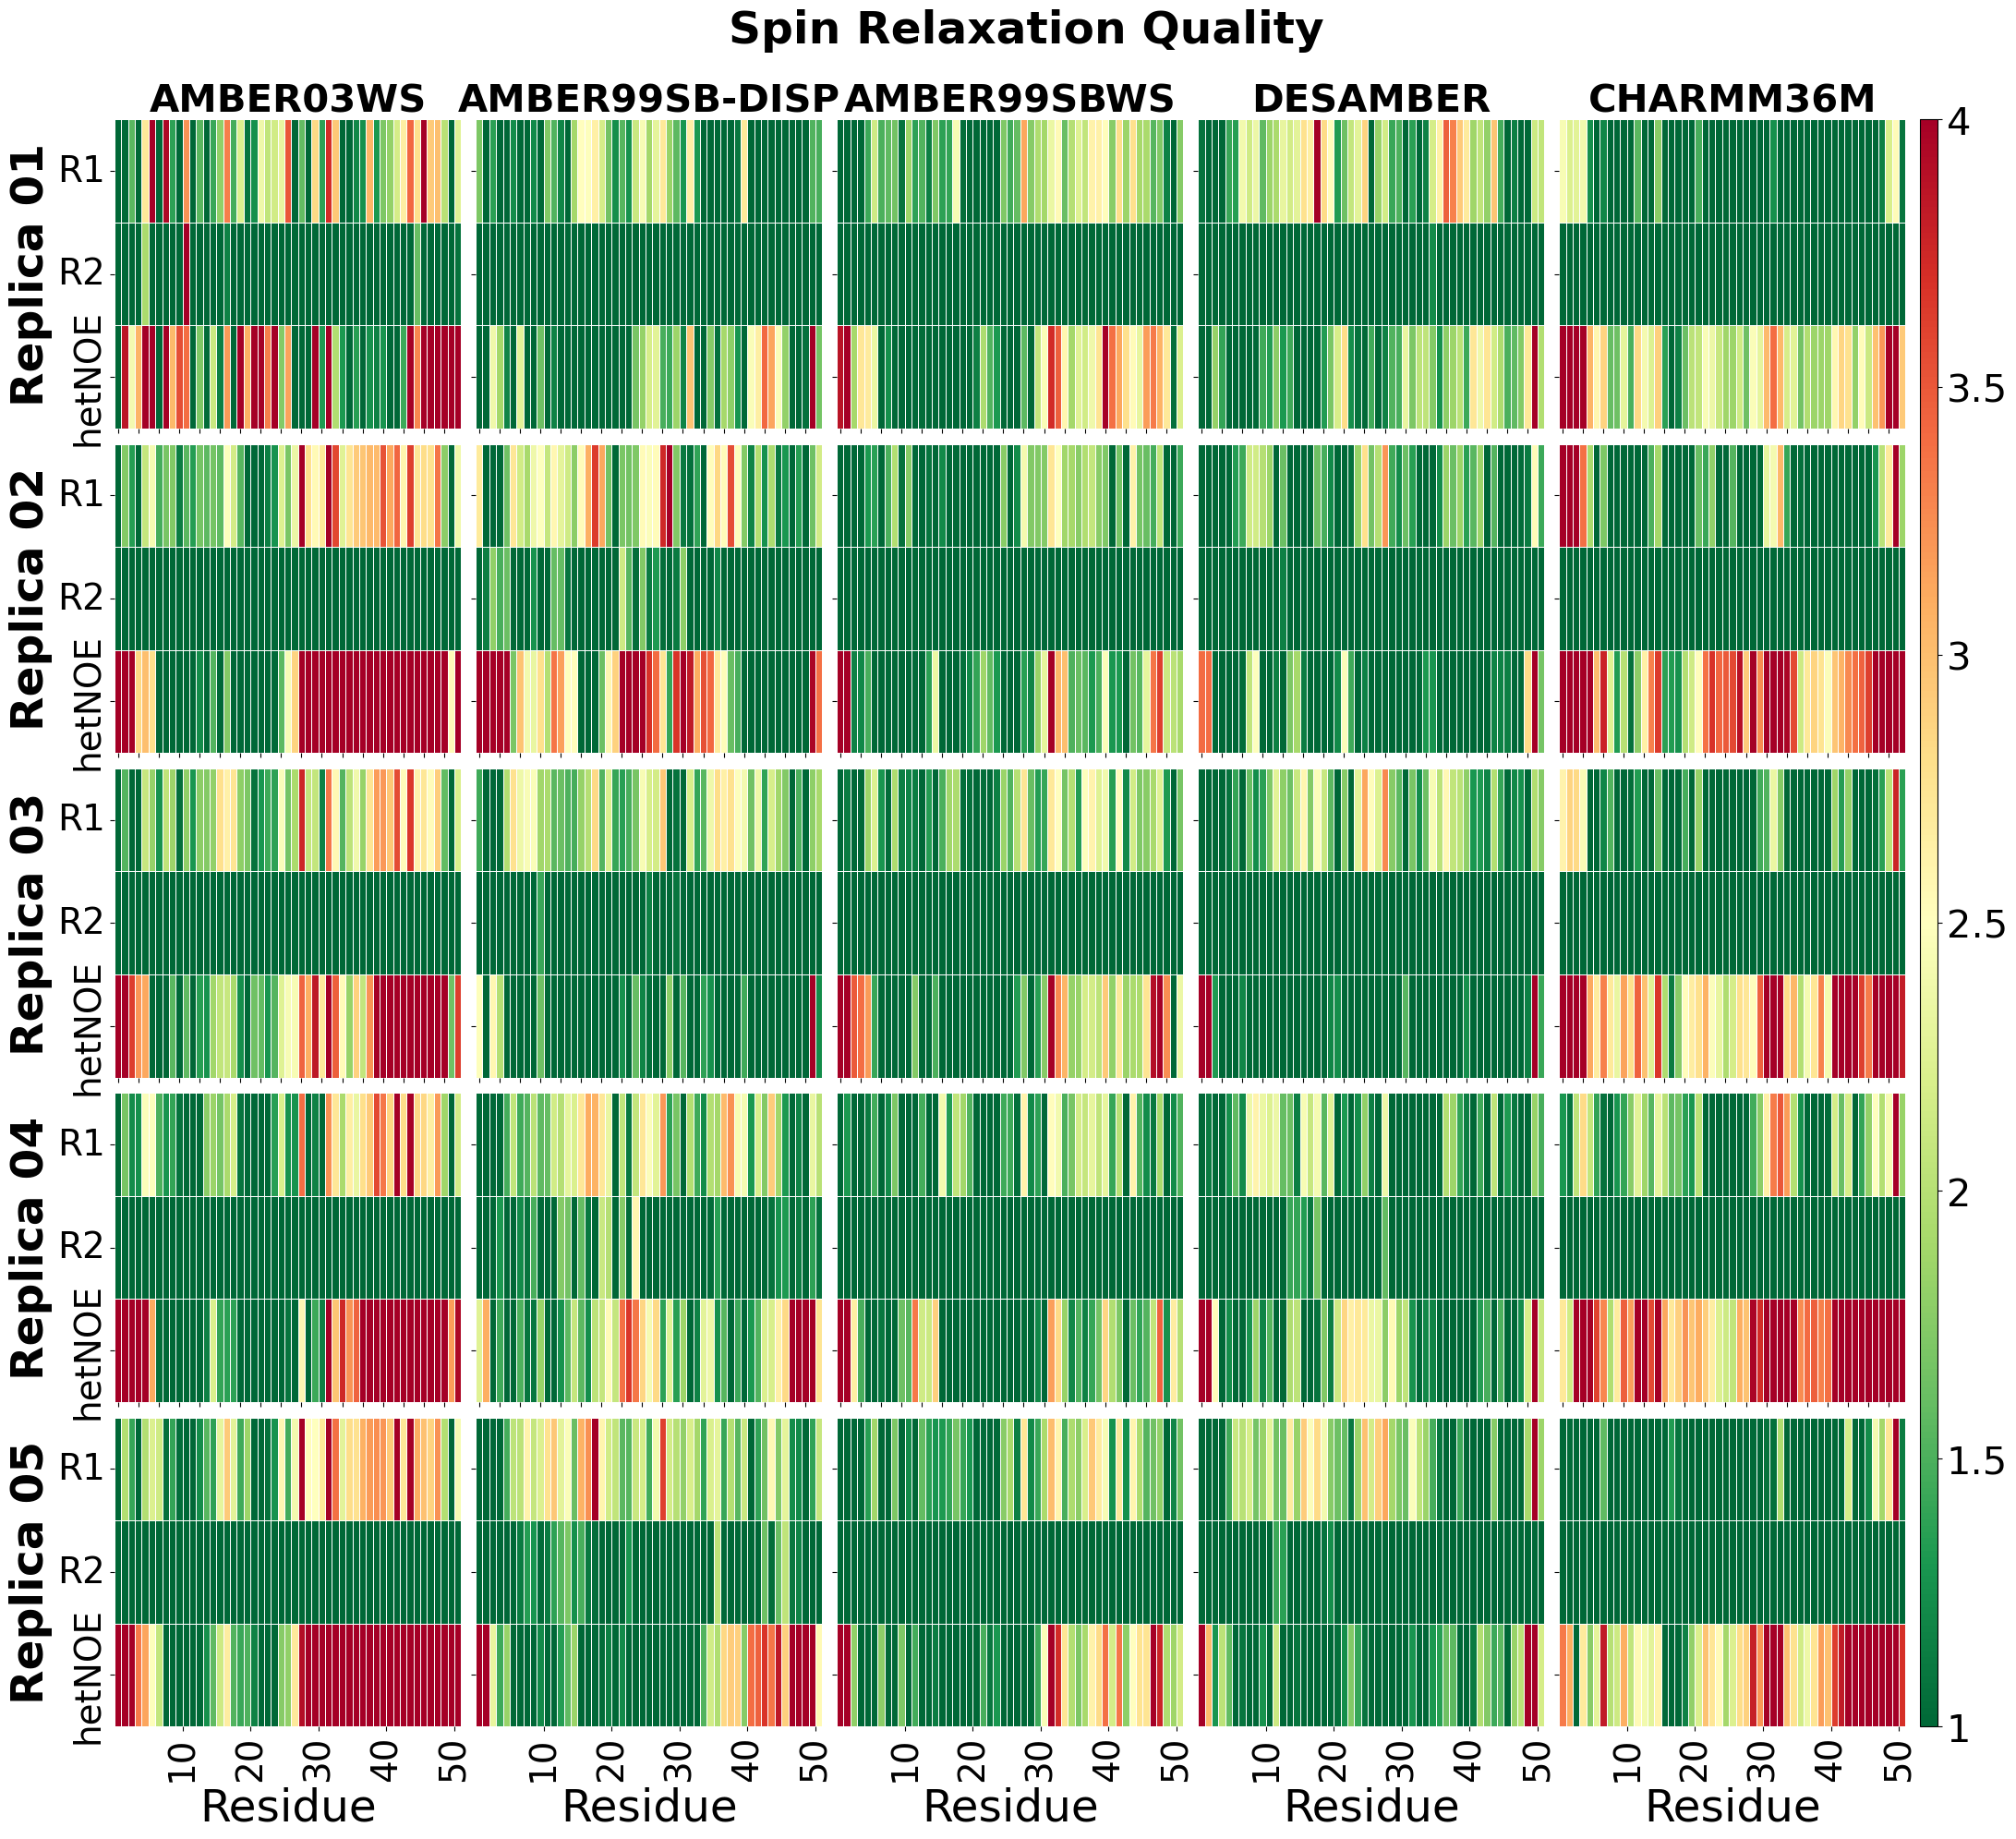

In [28]:
# Chemical shifts (YAML assumed!)
fig = plot_heatmap_grid(
    type_name="Chemical Shift Quality",
    yaml_filename="chemical_shift_quality.yaml",
    vmax=3
)

fig.savefig(protein_system + "_chemical_shift_quality.pdf", dpi=300, bbox_inches="tight")
fig.savefig(protein_system + "_chemical_shift_quality.png", dpi=300, bbox_inches="tight")

# Relaxation heatmaps
fig = plot_heatmap_grid(
    type_name="Spin Relaxation Quality",
    yaml_filename="spin_relaxation_quality.yaml",
    vmax=3
)

fig.savefig(protein_system + "_spin_relaxation_quality.pdf", dpi=300, bbox_inches="tight")
fig.savefig(protein_system + "_spin_relaxation_quality.png", dpi=300, bbox_inches="tight")
